In [84]:
%load_ext autoreload
%autoreload 2

# 0. 所有的组

In [2]:
import pandas as pd
import numpy as np
import vectorbt as vbt

In [3]:
# 准备数据
market = pd.read_parquet("../data_ohlcv.parquet")
f_mev = pd.read_parquet("../factors_mev_new.parquet")
f_ohlcv = pd.read_parquet("../factors_ohlcv.parquet")
f_ohlcv = f_ohlcv.fillna(0)
target_returns = market['close'].pct_change().shift(-1) 
factors = pd.concat([f_mev, f_ohlcv], axis=1, join='outer')
# 清洗数据
factors = factors.replace([np.inf, -np.inf], np.nan)
factors = factors.fillna(0)

In [ ]:
group_names = {
    0: "Medium_Term_Momentum_Exhaustion",  # （有效）48周期的动量/资金流指标，IC为负，反映中线趋势的衰竭
    1: "Short_Term_Volume_Price_Consistency", # （有效）6-12周期的价量相关性，核心是判断量价配合的真伪
    2: "Neutral_Price_Ranking",            # 纯Rank类因子，IC近乎0，属于无效的截面位置指标
    3: "Short_Term_Money_Flow_Reversion",   # （有效）CMF/MFI/AVR 组合，极短线资金流向带来的反转信号
    4: "Short_Term_Price_Floor_Distance",   # （有效）价格距离6-12周期低点的位移，典型的超跌反转逻辑
    5: "Volatility_and_Realized_Risk",      # ATR/GKVol/RVol 组合，衡量波动率和风险分布
    6: "Volume_Surge_and_Delta_Inertia",    # 成交量突变与Delta（净主动买入）的微观特征
    7: "Medium_Term_Overbought_Oversold",   # （有效）48周期的ROC/CCI/DRP，反映中期维度的价格乖离
    8: "Medium_Term_Volatility_Profile",    # 48周期的波动率属性，属于长窗期的风险度量
    9: "Statistical_Tail_Risk_Features",    # 偏度(Skew)与峰度(Kurt)，刻画收益率分布的肥尾特征
    10: "Aggressive_Short_Term_Mean_Reversion", # （有效）核心组：6-12周期极短线反转，涵盖了最强的alpha来源
    11: "DEX factors"                        # 链上特征
}

In [ ]:
group_split = [['roc_48', 'mfi_48', 'avr_48', 'pvcorr_48', 'corr_48'],\
                ['pvcorr_6', 'pvcorr_12', 'corr_6', 'corr_12'], \
                ['rank_6', 'rank_12', 'rank_48'], \
                ['cmf_6', 'cmf_12', 'cmf_48', 'mfi_12', 'avr_6', 'avr_12'],\
                ['dist_l_6', 'dist_l_12'], \
                ['atr_6', 'atr_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12'], \
                ['volsu_6', 'volsu_12', 'volsu_48', 'delta_6', 'delta_12', 'delta_48'],\
                ['roc_12', 'madev_48', 'cci_48', 'dist_h_48', 'dist_l_48', 'drp_48'], \
                ['atr_48', 'gkvol_48', 'rvol_48'], \
                ['skew_6', 'skew_12', 'skew_48', 'kurt_6', 'kurt_12', 'kurt_48'], \
                ['roc_6', 'madev_6', 'madev_12', 'cci_6', 'cci_12', 'dist_h_6', 'dist_h_12', 'mfi_6', 'drp_6', 'drp_12'], \
                ['f_sandwich_intensity_z','f_mev_vol_share_z','f_attack_eff_z']]
print(group_split)

[['roc_48', 'mfi_48', 'avr_48', 'pvcorr_48', 'corr_48'], ['pvcorr_6', 'pvcorr_12', 'corr_6', 'corr_12'], ['rank_6', 'rank_12', 'rank_48'], ['cmf_6', 'cmf_12', 'cmf_48', 'mfi_12', 'avr_6', 'avr_12'], ['dist_l_6', 'dist_l_12'], ['atr_6', 'atr_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12'], ['volsu_6', 'volsu_12', 'volsu_48', 'delta_6', 'delta_12', 'delta_48'], ['roc_12', 'madev_48', 'cci_48', 'dist_h_48', 'dist_l_48', 'drp_48'], ['atr_48', 'gkvol_48', 'rvol_48'], ['skew_6', 'skew_12', 'skew_48', 'kurt_6', 'kurt_12', 'kurt_48'], ['roc_6', 'madev_6', 'madev_12', 'cci_6', 'cci_12', 'dist_h_6', 'dist_h_12', 'mfi_6', 'drp_6', 'drp_12'], ['f_sandwich_intensity_z'], ['f_mev_vol_share_z'], ['f_attack_eff_z']]


In [13]:
group_eff = []
# 筛选一下组内平均因子ic
for group_id in range(len(group_split)):
    print(f"Group {group_id}:")
    group_ic = []
    factor_list = group_split[group_id]
    for factor in factor_list:
        ic = factors[factor].corr(target_returns, method='spearman')
        group_ic.append(ic)
        print(f"  {factor}: {ic:.4f}")
    print(f"  Group {group_id} : Average IC = {np.mean(np.abs(group_ic)):.4f}")
    if np.mean(np.abs(group_ic)) > 0.01 : group_eff.append(group_id)
print(f"Effective Groups: {group_eff}")

Group 0:
  roc_48: -0.0248
  mfi_48: -0.0182
  avr_48: -0.0191
  pvcorr_48: -0.0130
  corr_48: -0.0075
  Group 0 : Average IC = 0.0165
Group 1:
  pvcorr_6: -0.0306
  pvcorr_12: -0.0260
  corr_6: -0.0242
  corr_12: -0.0208
  Group 1 : Average IC = 0.0254
Group 2:
  rank_6: -0.0005
  rank_12: -0.0001
  rank_48: 0.0006
  Group 2 : Average IC = 0.0004
Group 3:
  cmf_6: -0.0444
  cmf_12: -0.0349
  cmf_48: -0.0170
  mfi_12: -0.0380
  avr_6: -0.0482
  avr_12: -0.0382
  Group 3 : Average IC = 0.0368
Group 4:
  dist_l_6: -0.0419
  dist_l_12: -0.0406
  Group 4 : Average IC = 0.0412
Group 5:
  atr_6: -0.0019
  atr_12: -0.0024
  gkvol_6: 0.0044
  gkvol_12: 0.0035
  rvol_6: 0.0037
  rvol_12: 0.0032
  Group 5 : Average IC = 0.0032
Group 6:
  volsu_6: -0.0003
  volsu_12: 0.0005
  volsu_48: 0.0010
  delta_6: 0.0008
  delta_12: 0.0026
  delta_48: -0.0007
  Group 6 : Average IC = 0.0010
Group 7:
  roc_12: -0.0467
  madev_48: -0.0403
  cci_48: -0.0403
  dist_h_48: -0.0357
  dist_l_48: -0.0309
  drp_48: -

In [31]:
group_eff = [0, 1, 3, 4, 7, 9, 10]  # 有效组的索引

pvcorr_6 Spearman IC with Target Returns: -0.0329


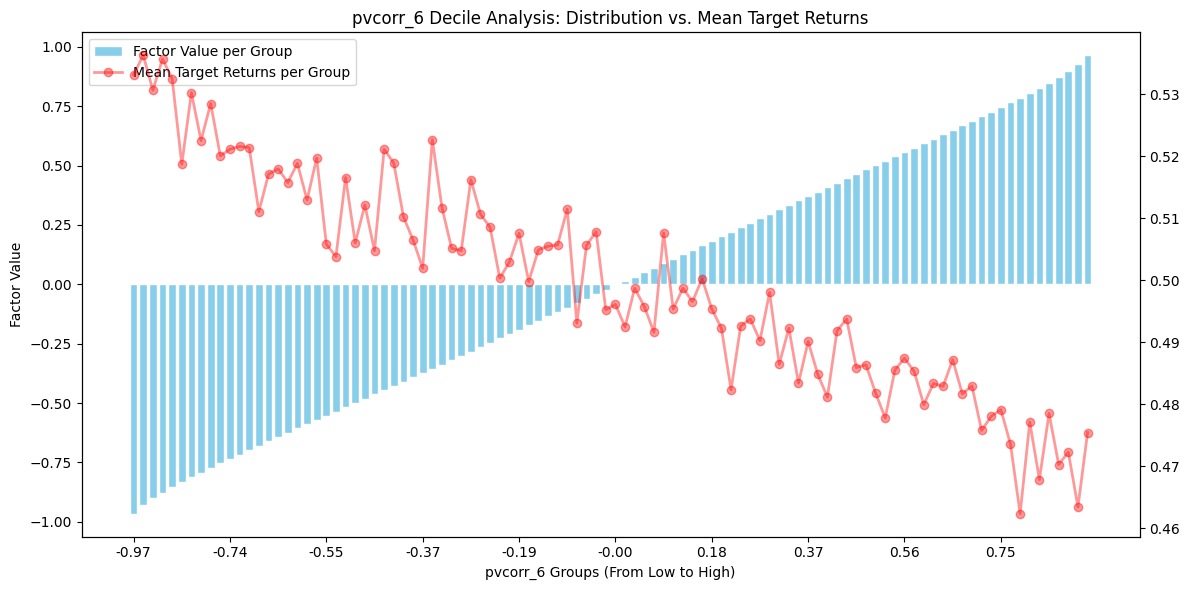

pvcorr_12 Spearman IC with Target Returns: -0.0286


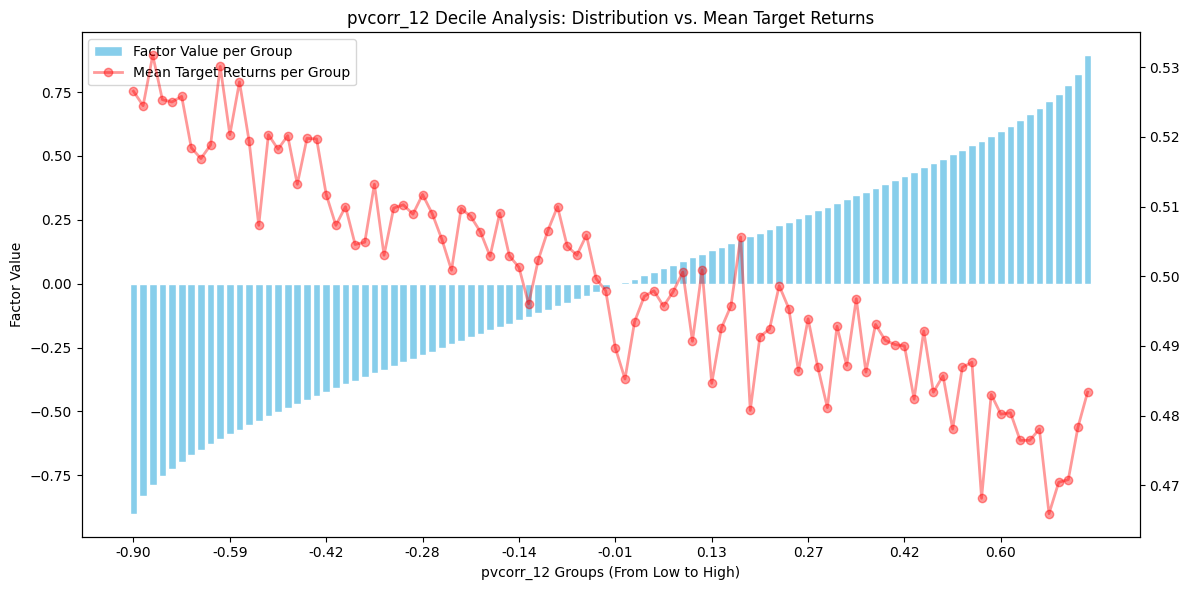

corr_6 Spearman IC with Target Returns: -0.0276


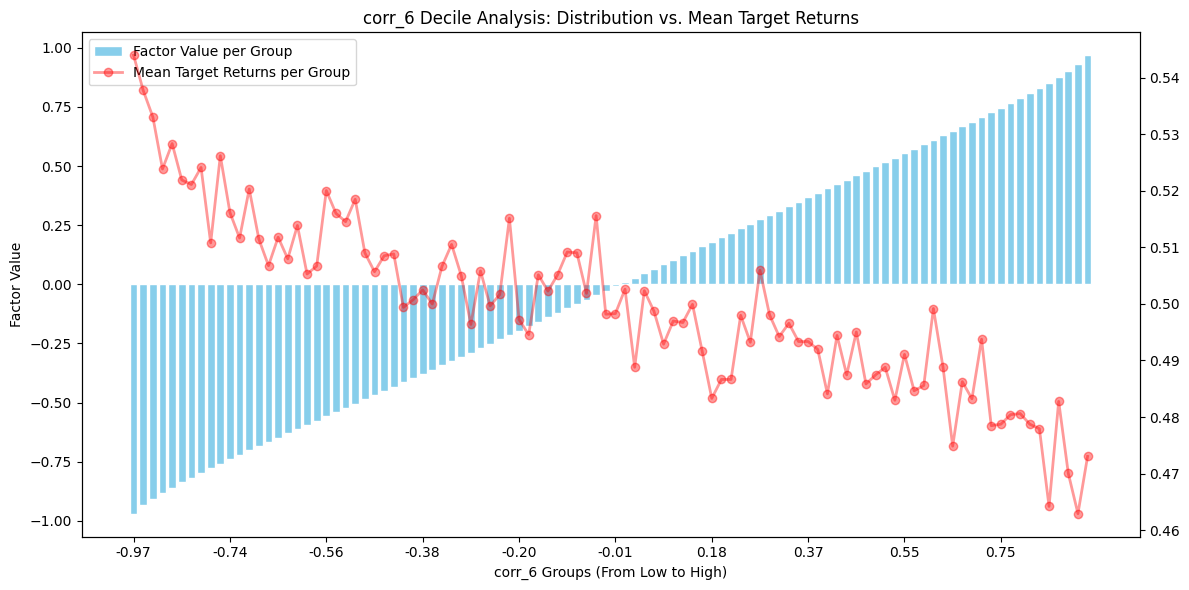

corr_12 Spearman IC with Target Returns: -0.0236


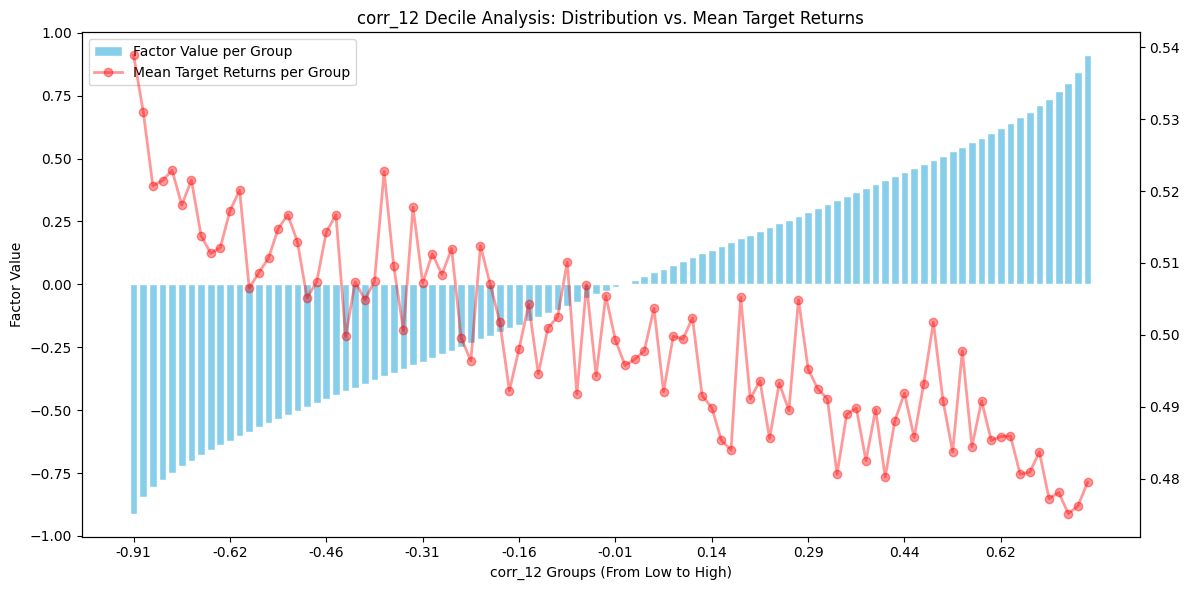

In [19]:
from test_tools import plot_factor_ic_bar
for factor in group_split[1]: 
    ic = factors[factor].corr(target_returns>0, method='spearman')
    print(f"{factor} Spearman IC with Target Returns: {ic:.4f}")
    plot_factor_ic_bar(factors[factor], target_returns>0, factor_name=factor, result_name="Target Returns", bins=100)

# 1. 组内合成

Group 0 Spearman IC with Win Rate : 0.0210


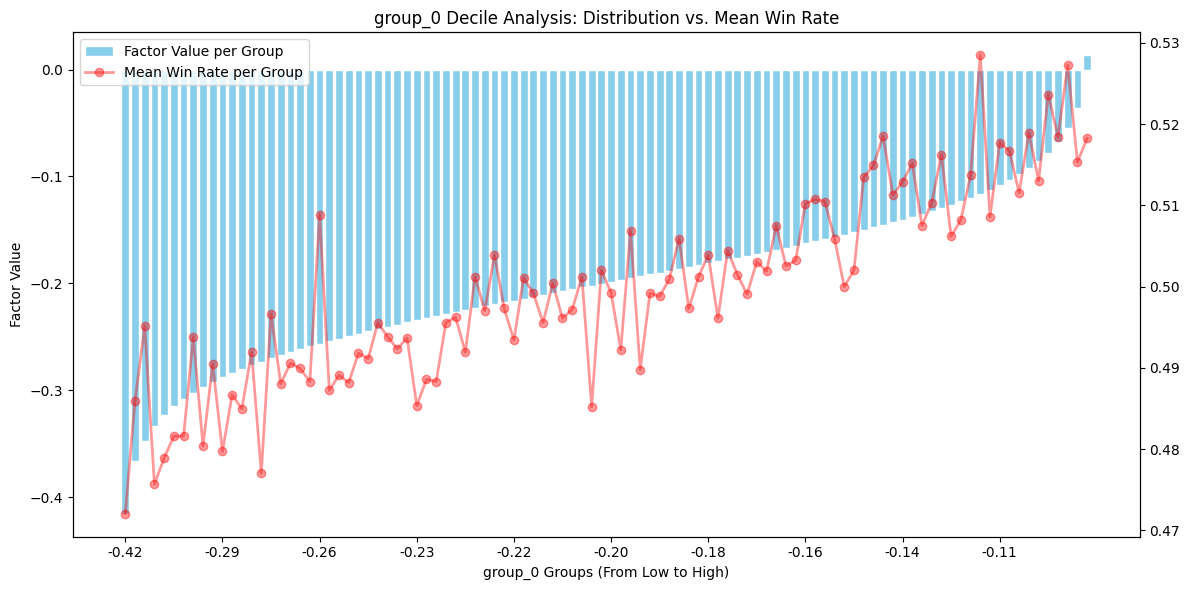

Group 1 Spearman IC with Win Rate : 0.0338


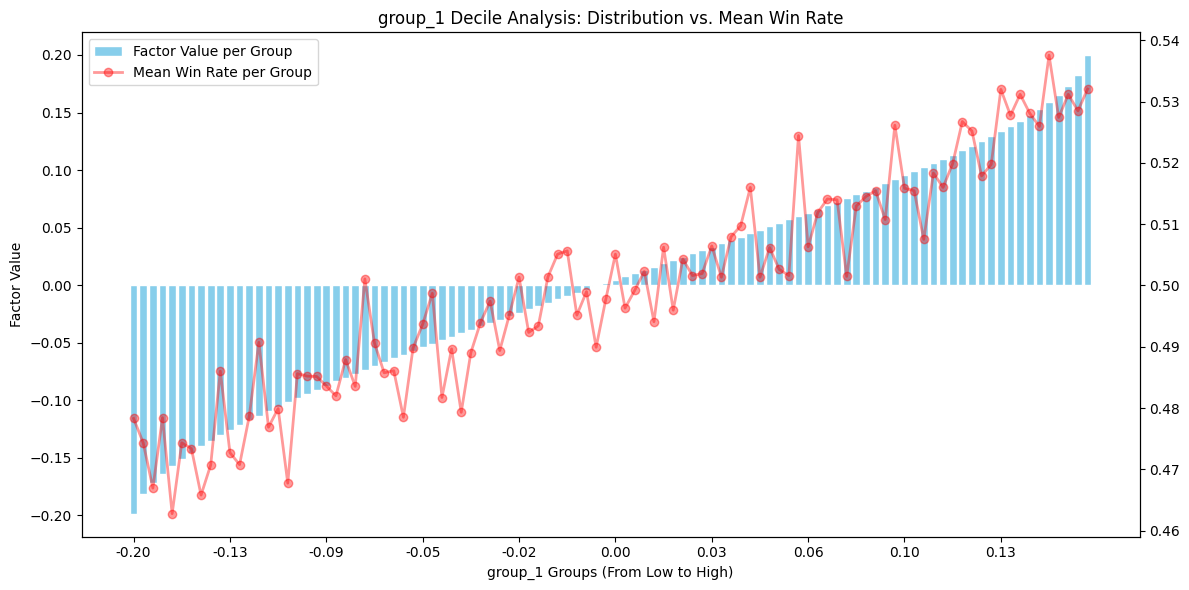

Group 3 Spearman IC with Win Rate : 0.0540


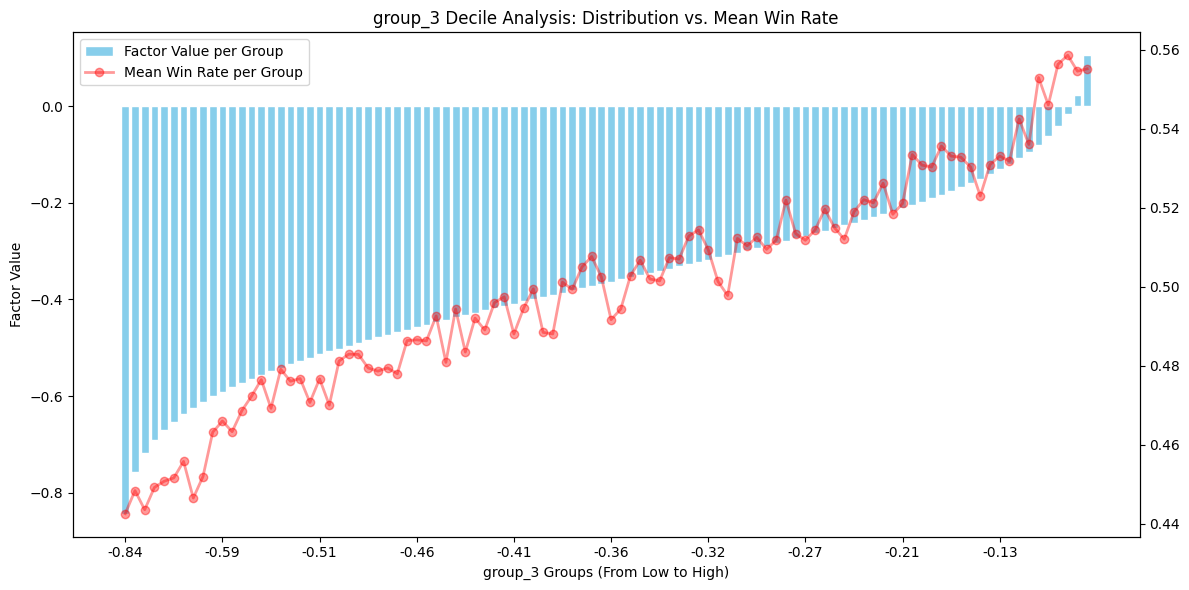

Group 4 Spearman IC with Win Rate : 0.0417


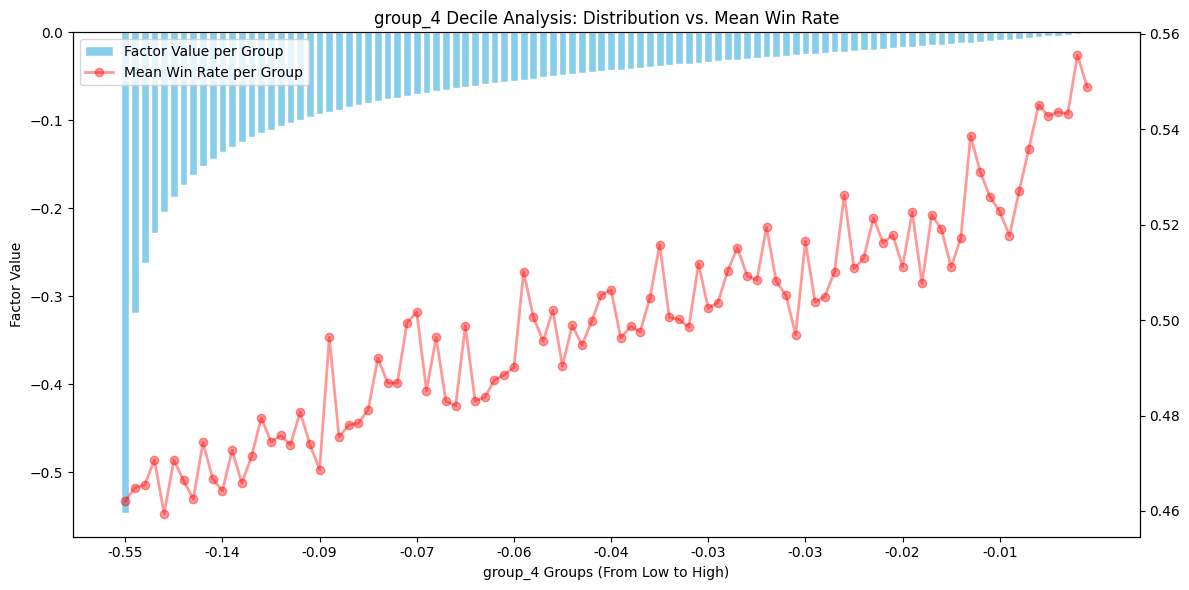

Group 7 Spearman IC with Win Rate : 0.0489


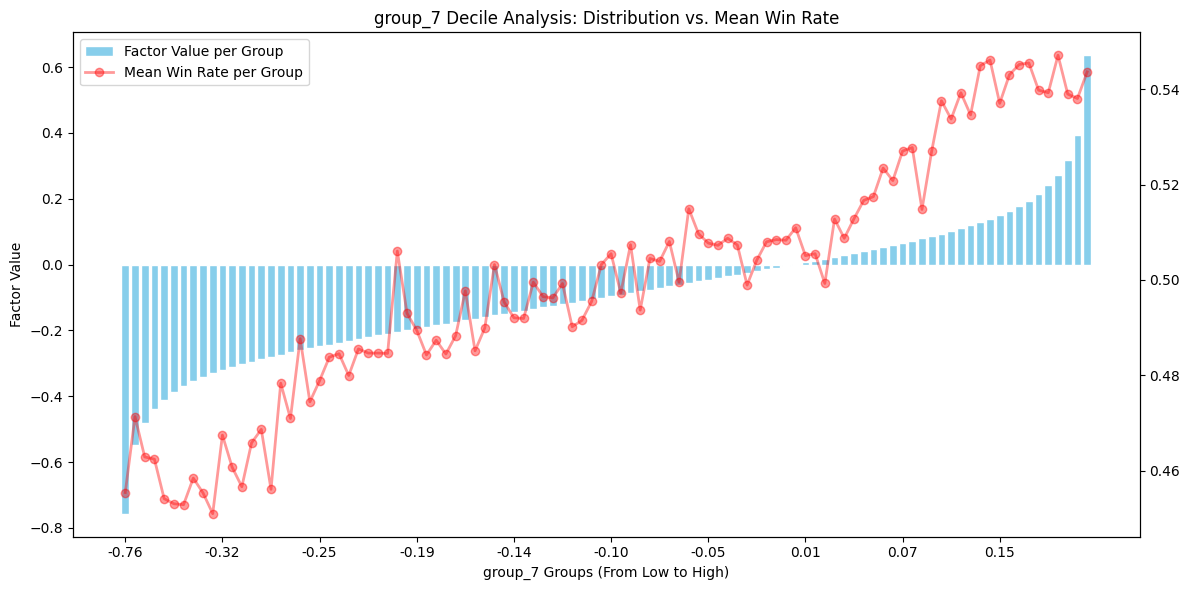

Group 9 Spearman IC with Win Rate : 0.0437


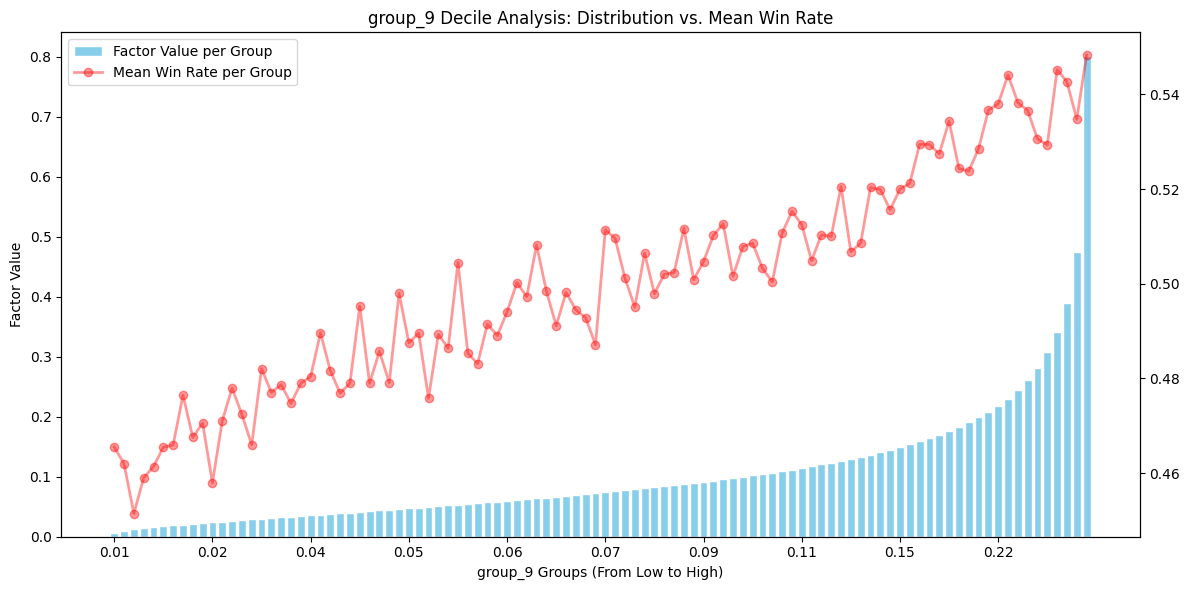

Group 10 Spearman IC with Win Rate : 0.0658


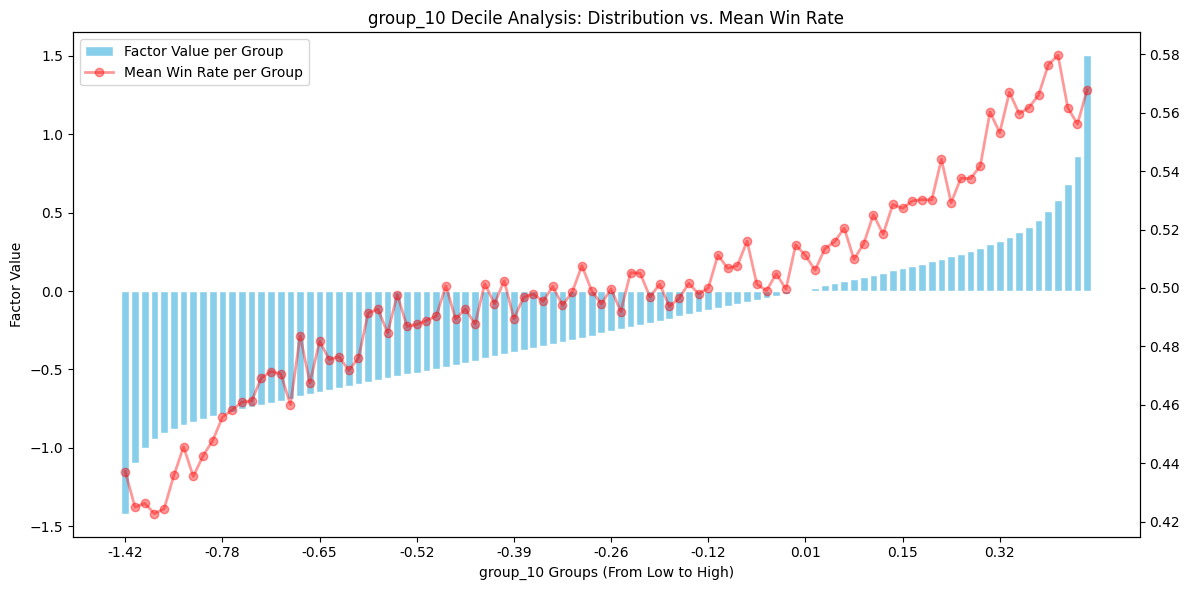

In [30]:
df_final = pd.DataFrame(index=factors.index)

for i in[0, 1, 3, 4, 7, 9, 10]:
    df_final[f"group_{i}"] = 0
    for factor in group_split[i]:
        ic = factors[factor].corr(target_returns>0, method='spearman')
        std = factors[factor].std()
        df_final[f"group_{i}"] += factors[factor] * ic / std
    final_ic = df_final[f"group_{i}"][df_final[f"group_{i}"]!=0].corr(target_returns>0, method='spearman')
    print(f"Group {i} Spearman IC with Win Rate : {final_ic:.4f}")
    plot_factor_ic_bar(df_final[f"group_{i}"][df_final[f"group_{i}"]!=0], target_returns>0, factor_name=f"group_{i}", result_name="Win Rate", bins=100)

# 2. 组间合成 （启发式curve）

In [23]:
df_final.describe()

,group_0,group_1,group_3,group_4,group_7,group_9,group_10
count,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000
mean,-0.199528,0.002422,-0.365502,-0.065137,-0.093107,0.104381,-0.242122
std,0.073185,0.095499,0.179395,0.080317,0.206211,0.114962,0.468399
min,-0.893548,-0.228663,-1.146753,-6.681988,-4.381418,0.000000,-13.018981
25%,-0.245856,-0.071780,-0.486806,-0.081281,-0.222937,0.040597,-0.588125
50%,-0.199353,0.003088,-0.365340,-0.043518,-0.098005,0.073037,-0.263134
75%,-0.153032,0.077099,-0.243839,-0.021144,0.031828,0.127839,0.069216
max,0.578492,0.228701,0.407715,0.000000,4.089533,5.833865,13.261730


In [ ]:
# 算了先线性合成试试万一成了呢

Final Alpha Spearman IC with Win Rate: 0.0620


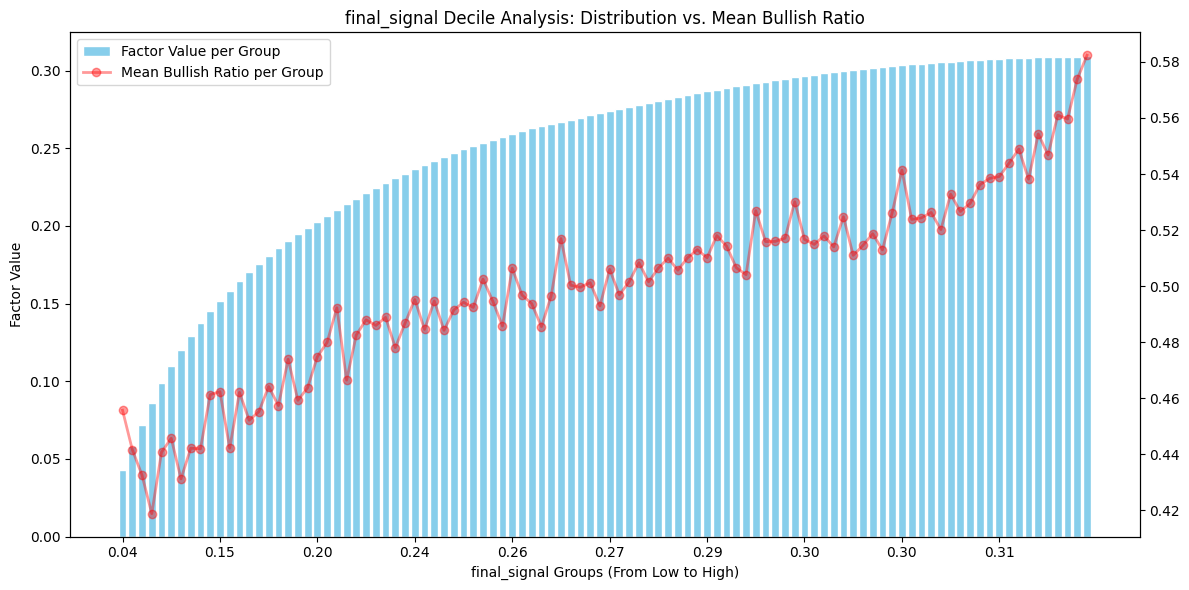

In [53]:
# 对每个组进行curve
import numpy as np

def pseudo_zero_one(series, threshold=0.5, k=5):
    """
    threshold: 只有超过这个分位数的信号才开始激活 (0.7 代表前 30%)
    k: 斜率。k 越大，函数越接近硬性的 0/1 阶梯
    """
    # 1. 滚动 Rank (144 bar 约为 12 小时)
    # 如果你不想滚动，直接用 rank(pct=True) 也可以，但滚动更实盘
    r = series.rank(pct=True)
    
    # 2. 只有正向极性处理 (Group 3 这种负向的需要先取绝对值或反向)
    # 假设我们已经把所有组都调成了“数值越大波幅越大”
    
    x_shifted = np.maximum(0, r - threshold)
    
    # 3. 映射到 0-1
    # 缩放 x 让它在 threshold 到 1 之间能覆盖 exp 的主要变化区
    # 当 r=1 时，exp(-k*(1-threshold)) 应该接近 0
    return (1 - np.exp(-k * x_shifted))**3

# 假设 df_final 是你贴出的那个 DataFrame


groups_to_process = group_eff  # 只处理有效组

# 2. 批量生成“伪 01”信号
df_signals = pd.DataFrame(index=df_final.index)
df_final['final_alpha'] = 0
for col in groups_to_process:
    # 选 threshold=0.7 是为了过滤底噪，k=10 会让斜率在 0.7 之后迅速变陡
    df_signals[f"{col}_sig"] = pseudo_zero_one(df_final[f"group_{col}"], threshold=0.01, k=10)
    ic = df_signals[f"{col}_sig"].corr(target_returns>0, method='spearman')
    df_final['final_alpha'] += df_signals[f"{col}_sig"] * ic   # 用 IC 作为权重
# 3. 最终加权投票 (既然目测 0.28 和 0.32 没差，直接等权)

# 4. 评估最终 alpha 的 IC
final_ic = df_final['final_alpha'].corr(target_returns>0, method='spearman')
print(f"Final Alpha Spearman IC with Win Rate: {final_ic:.4f}")
plot_factor_ic_bar(df_final['final_alpha'], target_returns>0, factor_name='final_signal', result_name="Bullish Ratio", bins=100)

In [56]:
df_final_2= pd.read_parquet("final_signal.parquet")
df_final_2["directions"] = df_final["final_alpha"]
print(df_final_2.head(2))
df_final_2.to_parquet("final_signal_with_direction.parquet")

                     group_0  group_1  group_2  group_3  group_4  group_5  \
2019-01-01 00:00:00      0.0      0.0      0.0      0.0      0.0      0.0   
2019-01-01 00:05:00      0.0      0.0      0.0      0.0      0.0      0.0   

                     group_6  group_7   group_8   group_9  group_3_aligned  \
2019-01-01 00:00:00      0.0      0.0  0.027121  0.055668             -0.0   
2019-01-01 00:05:00      0.0      0.0  0.027033  0.054585             -0.0   

                     final_alpha  directions  
2019-01-01 00:00:00          0.0    0.264319  
2019-01-01 00:05:00          0.0    0.264319  


# 终极测试（回测）

In [136]:
# 1. 计算上下分位数阈值（以两端各 10% 为例）
lower_threshold = df_final_2['final_alpha'].quantile(0.10)
upper_threshold = df_final_2['final_alpha'].quantile(0.90)

# 2. 执行三值化映射：大于高阈值为 1，小于低阈值为 -1，中间为 0
df_final_2['signal'] = 0  # 初始化为 0
df_final_2.loc[(df_final_2['directions'] >= 0.25) & (df_final_2['final_alpha'] > 0.4), 'signal'] = 1
df_final_2.loc[(df_final_2['directions'] <= 0.1) & (df_final_2['final_alpha'] > 0.4), 'signal'] = -1

df_final_2["return"] = target_returns

In [147]:
import pandas as pd
import numpy as np

def run_backtest(df, signal_col='signal', return_col='return', leverage=1.0):
    """
    简易向量化回测函数
    :param df: 包含预测因子和实际收益率的 DataFrame
    :param signal_col: 你的模型输出评分（或者直接是预测的 0/1）
    :param return_col: 实际的未来收益率（注意：应该是 t+1 期的 return）
    """
    backtest_df = df.copy()
    
    # 1. 生成交易信号：这里假设 final_alpha > 0.5 (或中位数) 为多头，否则为空头
    # 如果你做了三值化映射，可以直接用 -1, 0, 1
    backtest_df['position'] = backtest_df[signal_col]
    fee = 0.5 *0.0001* backtest_df['position'].abs()  # 每次换仓的手续费，假设 0.1% 
    # 2. 计算每日收益 (策略收益 = 仓位 * 实际收益率)
    backtest_df['strategy_return'] = backtest_df['position'] * backtest_df[return_col] * leverage - fee
    
    # 3. 计算累计收益
    backtest_df['cum_ret'] = (1 + backtest_df['strategy_return']).cumprod()
    backtest_df['cum_benchmark'] = (1 + backtest_df[return_col]).cumprod()
    
    # 4. 计算核心指标
    total_ret = backtest_df['cum_ret'].iloc[-2] - 1
    annual_ret = (1 + total_ret) ** (252 * 288 / len(backtest_df)) - 1  # 假设年化 252 个交易日
    annual_vol = backtest_df['strategy_return'].std() * np.sqrt(252)
    sharpe_ratio = annual_ret / annual_vol if annual_vol != 0 else 0
    
    # 计算最大回撤
    rolling_max = backtest_df['cum_ret'].cummax()
    drawdown = (backtest_df['cum_ret'] - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # 胜率 (方向预测准确的比例)
    win_rate = (np.sign(backtest_df['position']) == np.sign(backtest_df[return_col])).sum() / (backtest_df['position']!=0).count()

    print(f"--- 回测报告 ---")
    print(f"累计收益率: {total_ret:.2%}")
    print(f"年化收益率: {annual_ret:.2%}")
    print(f"年化波动率: {annual_vol:.2%}")
    print(f"夏普比率: {sharpe_ratio:.2f}")
    print(f"最大回撤: {max_drawdown:.2%}")
    print(f"实际胜率: {win_rate:.2%}")
    
    return backtest_df

# 调用示例
results = run_backtest(df_final_2)

--- 回测报告 ---
累计收益率: -99.73%
年化收益率: -43.80%
年化波动率: 2.56%
夏普比率: -17.11
最大回撤: -99.74%
实际胜率: 15.93%


--- 回测报告 ---
累计收益率: 1908.61%
年化收益率: 38.71%
年化波动率: 2.56%
夏普比率: 15.12
最大回撤: -65.13%
实际胜率: 15.93%


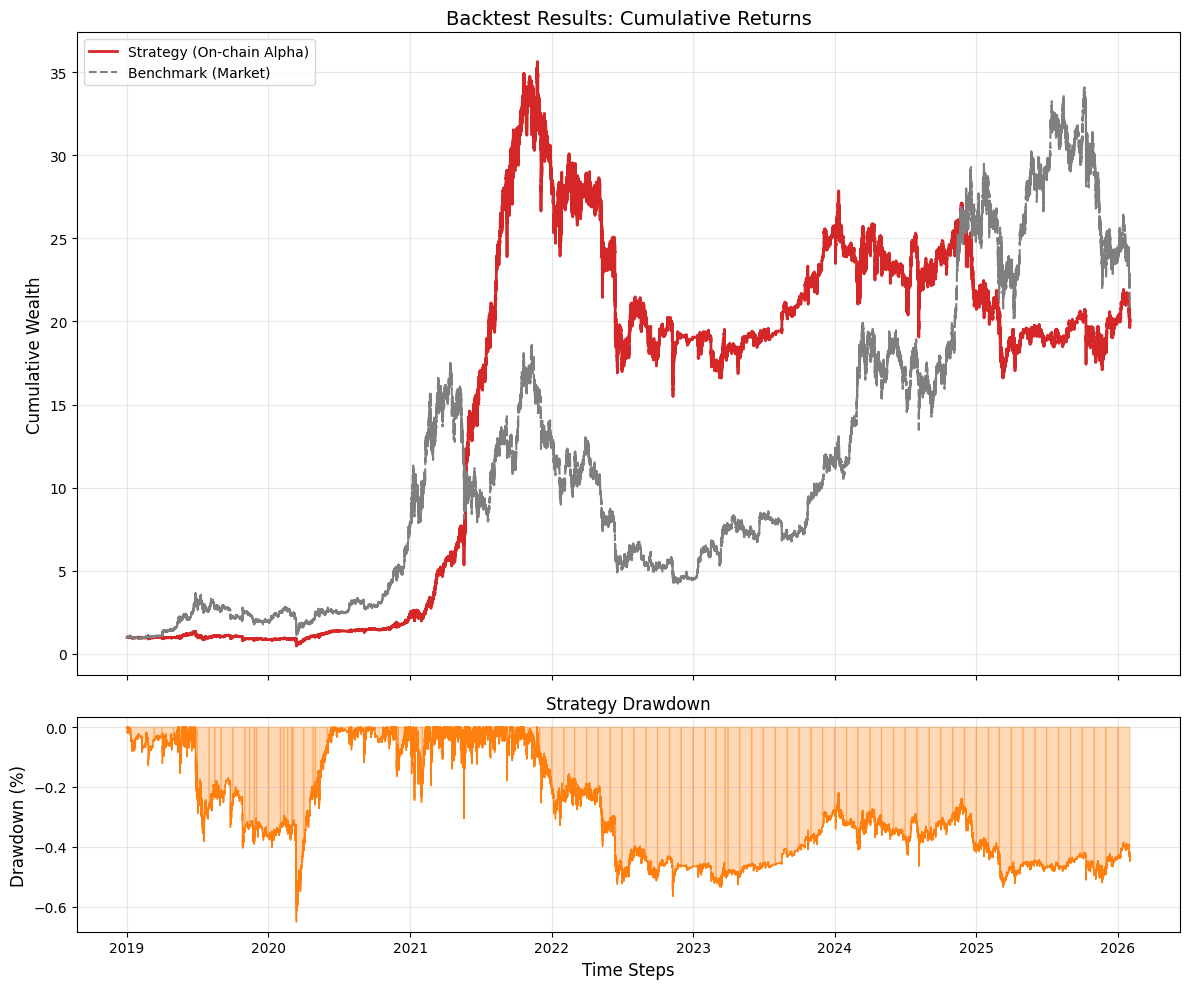

In [119]:
import matplotlib.pyplot as plt

def plot_backtest_results(results):
    """
    绘制回测净值曲线和回撤图
    :param results: run_backtest 函数返回的 DataFrame
    """
    # 设置画板大小
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # --- 图 1: 累计收益曲线 ---
    ax1.plot(results.index, results['cum_ret'], label='Strategy (On-chain Alpha)', color='#d62728', lw=2)
    ax1.plot(results.index, results['cum_benchmark'], label='Benchmark (Market)', color='#7f7f7f', lw=1.5, linestyle='--')
    
    ax1.set_title('Backtest Results: Cumulative Returns', fontsize=14)
    ax1.set_ylabel('Cumulative Wealth', fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # --- 图 2: 最大回撤曲线 ---
    rolling_max = results['cum_ret'].cummax()
    drawdown = (results['cum_ret'] - rolling_max) / rolling_max
    
    ax2.fill_between(results.index, drawdown, 0, color='#ff7f0e', alpha=0.3, label='Drawdown')
    ax2.plot(results.index, drawdown, color='#ff7f0e', lw=1)
    
    ax2.set_title('Strategy Drawdown', fontsize=12)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Time Steps', fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 使用方法：
results = run_backtest(df_final_2)
plot_backtest_results(results)

# 3. 组间合成 （逻辑回归）

In [38]:
(target_returns > 0).astype(int).mean()

np.float64(0.49978238851441203)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

def run_logistic_regression(X, y):
    """
    执行逻辑回归的训练与评估
    :param X: 特征数据 (Array-like)
    :param y: 标签数据 (Array-like)
    """
    # 1. 划分训练集与测试集 (80% 训练, 20% 测试)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. 初始化模型
    # solver='lbfgs' 是默认优化算法，适合大多数小到中型数据集
    model = LogisticRegression(max_iter=1000)

    # 3. 训练模型
    model.fit(X_train, y_train)

    # 4. 进行预测
    y_pred = model.predict(X_test)

    # 5. 评估结果
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"模型准确率: {accuracy:.2%}")
    print("\n详细分类报告:\n", classification_report(y_test, y_pred))
    
    return model

import numpy as np

def dual_sided_relu(X, percentile=30):
    """
    双向 ReLU 激活：只保留两端各 percentile% 的数据，中间归零
    :param X: 特征矩阵 (NumPy array)
    :param percentile: 保留两端的比例（例如 10 表示保留前 10% 和后 10%）
    """
    X_activated = X.copy()
    
    # 遍历每一列（每一个特征）
    for i in range(X_activated.shape[1]):
        col = X_activated[:, i]
        
        # 计算分位数阈值
        lower_bound = np.percentile(col, percentile)      # 比如第 10 分位数
        upper_bound = np.percentile(col, 100 - percentile) # 比如第 90 分位数
        
        # 执行“双向 ReLU”：在阈值中间的数据设为 0
        mask = (col > lower_bound) & (col < upper_bound)
        X_activated[mask, i] = 0
        
    return X_activated

# 使用示例

X = df_final[[f"group_{i}" for i in group_eff]].fillna(0)  # 选择有效组的特征
y = (target_returns > 0).astype(int)  # 二分类标签：上涨为1，下跌为0

# 2. 找到两者的共同索引（交集）
common_index = X.index.intersection(y.index)

# 3. 强制对齐并重新赋值
X_aligned = X.loc[common_index]
y_aligned = y.loc[common_index]

# X_extreme = dual_sided_relu(X_aligned.values, percentile=30) # 两端各取 10%
# model_extreme = run_logistic_regression(X_extreme, y_aligned)
# 4. 检查对齐后的长度是否一致
print(f"对齐后的样本量: {len(X_aligned)}")

# 5. 运行模型
model = run_logistic_regression(X_aligned.values, y_aligned.values)

对齐后的样本量: 744446
模型准确率: 52.46%

详细分类报告:
               precision    recall  f1-score   support

           0       0.53      0.52      0.53     74909
           1       0.52      0.53      0.52     73981

    accuracy                           0.52    148890
   macro avg       0.52      0.52      0.52    148890
weighted avg       0.52      0.52      0.52    148890



In [35]:
# 假设你已经运行了前面的 fit 步骤
X_train, X_test, y_train, y_test = train_test_split(X_aligned, y_aligned, test_size=0.2, random_state=42)
# 1. 对训练集进行预测
y_train_pred = model.predict(X_train)

# 2. 计算训练集准确率
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_train_pred)

# 3. 对比测试集准确率
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"训练集准确率: {train_accuracy:.2%}")
print(f"测试集准确率: {test_accuracy:.2%}")

训练集准确率: 52.52%
测试集准确率: 52.46%


ROC-AUC 值: 0.5369


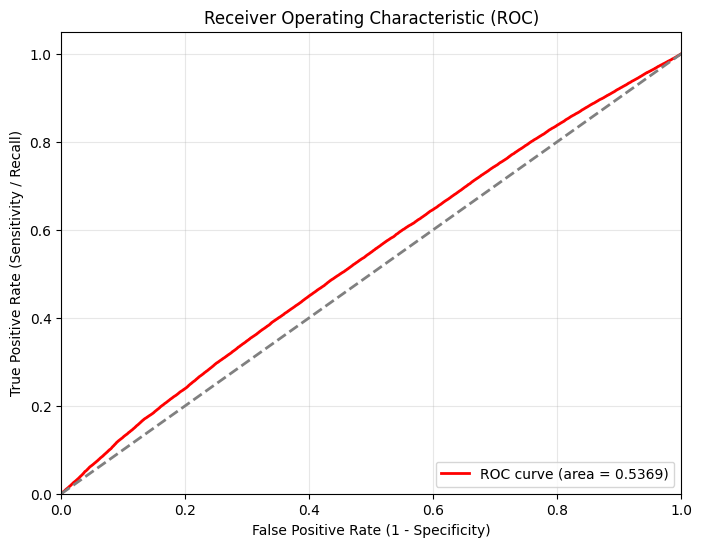

In [52]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def evaluate_roc_auc(model, X_test, y_test):
    # 1. 获取预测概率 (注意：逻辑回归要拿第二列，即类别 1 的概率)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # 2. 计算 AUC 值
    auc_value = roc_auc_score(y_test, y_probs)
    print(f"ROC-AUC 值: {auc_value:.4f}")
    
    # 3. 绘制 ROC 曲线
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (area = {auc_value:.4f})')
    plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--') # 对角线（随机猜测线）
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    return auc_value

# 调用
auc_score = evaluate_roc_auc(model, X_test, y_test)

# 11.  进行组内PCA
  但实际上组内PCA没有明显提升，甚至有些组的表现变差了，所以放弃了组内PCA

In [82]:
import numpy as np
import pandas as pd

def fast_rolling_pca(df_group, window=144):
    data = df_group.values
    n_samples, n_features = data.shape
    out = np.full(n_samples, np.nan)
    
    # 预先计算所有可能的滑动窗口索引 (或者直接用手动滑动)
    # 为了极致速度，我们只处理关键运算
    for i in range(window, n_samples):
        # 1. 快速 Robust Scaling (NumPy 向量化)
        chunk = data[i-window:i, :]
        median = np.median(chunk, axis=0)
        # 使用 percentile 替代 quantile
        q75, q25 = np.percentile(chunk, [75, 25], axis=0)
        iqr = q75 - q25
        iqr[iqr == 0] = 1e-6
        
        # 标准化当前窗口
        scaled_chunk = (chunk - median) / iqr
        
        # 2. 计算协方差矩阵 (C = X^T * X)
        # 对于 PC1，协方差矩阵足够了，n_features 很小，这一步极快
        cov_mat = np.cov(scaled_chunk, rowvar=False)
        
        # 3. 特征值分解 (只取最大的特征向量)
        # eigh 专门用于对称矩阵，比 eig 快且稳
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
        
        # eigenvalues 是升序的，取最后一个
        loading = eigenvectors[:, -1]
        
        # 4. 符号对齐
        if np.mean(loading) < 0:
            loading = -loading
            
        # 5. 投影当前行
        current_row_scaled = (data[i] - median) / iqr
        out[i] = np.dot(current_row_scaled, loading)
        
    return pd.Series(out, index=df_group.index)

In [19]:
group_eff = [0,8, 9]
for i in group_eff:
    factor_list = group_split[i]
    df_group = factors[factor_list]
    pca_signal = fast_rolling_pca(df_group, window=144)
    # 计算与目标的相关性
    ic = pca_signal.corr(target_returns.abs(), method='spearman')
    print(f"Group {i} PCA Signal Spearman IC: {ic:.4f}")

Group 0 PCA Signal Spearman IC: 0.1014
Group 8 PCA Signal Spearman IC: 0.1680
Group 9 PCA Signal Spearman IC: 0.1771


# 12. 因子相关性热力图

In [85]:
from test_tools import plot_factor_corr

ImportError: cannot import name 'plot_factor_corr' from 'test_tools' (/Users/vela/Desktop/mev/factor/backtest/test_tools.py)

In [23]:
for i in [0,3,8]:
    group_0 = factors[group_split[i]]
    sum_0 = group_0.sum(axis=1)
    corr = sum_0.corr(target_returns.abs(), method='spearman')
    print(f"Group {i} Sum Spearman Correlation with Target Returns Abs: {corr:.4f}")

Group 0 Sum Spearman Correlation with Target Returns Abs: 0.3141
Group 3 Sum Spearman Correlation with Target Returns Abs: -0.1191
Group 8 Sum Spearman Correlation with Target Returns Abs: 0.2526


Group 0 Correlation Heatmap:


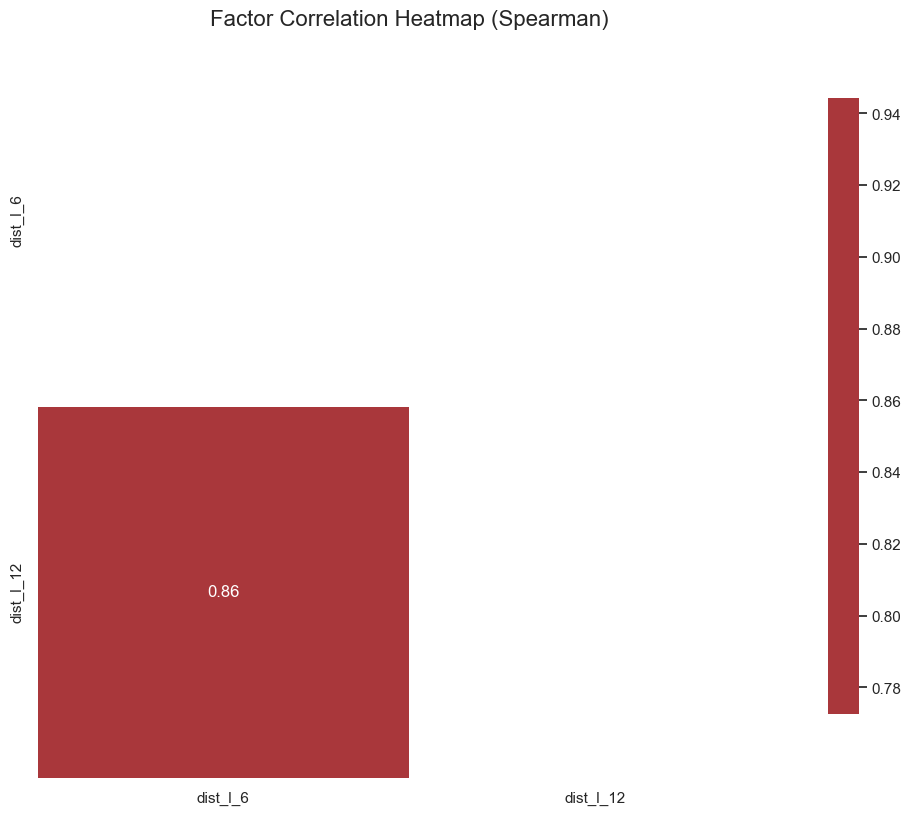

Group 0 Average Spearman IC: 0.3019
Group 3 Correlation Heatmap:


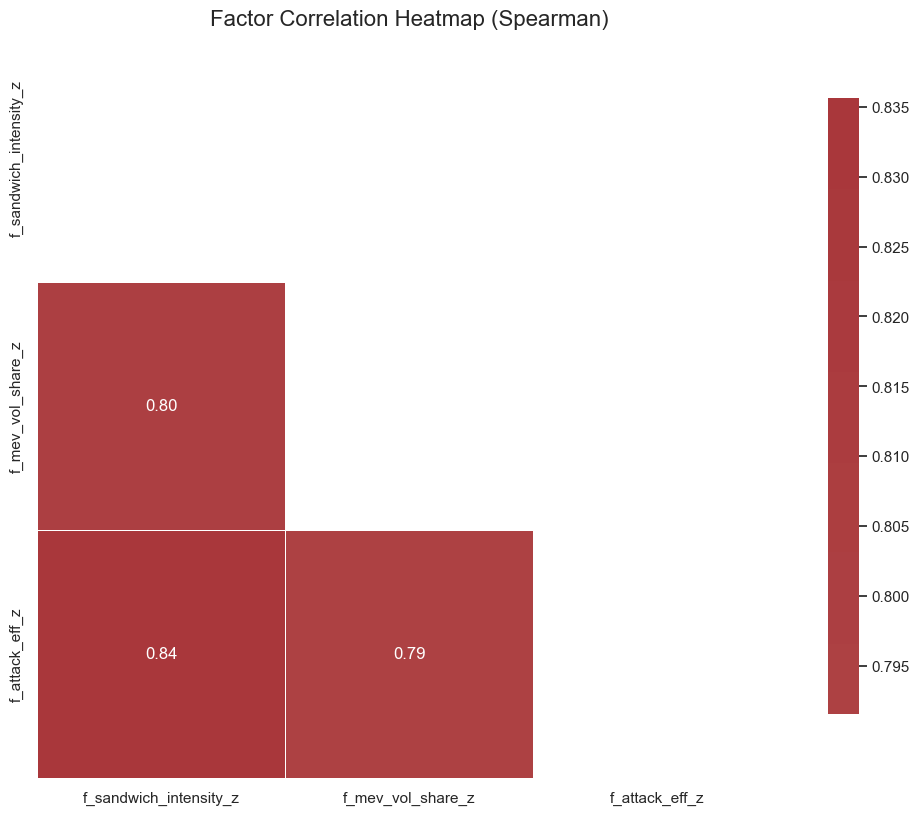

Group 3 Average Spearman IC: -0.1062
Group 8 Correlation Heatmap:


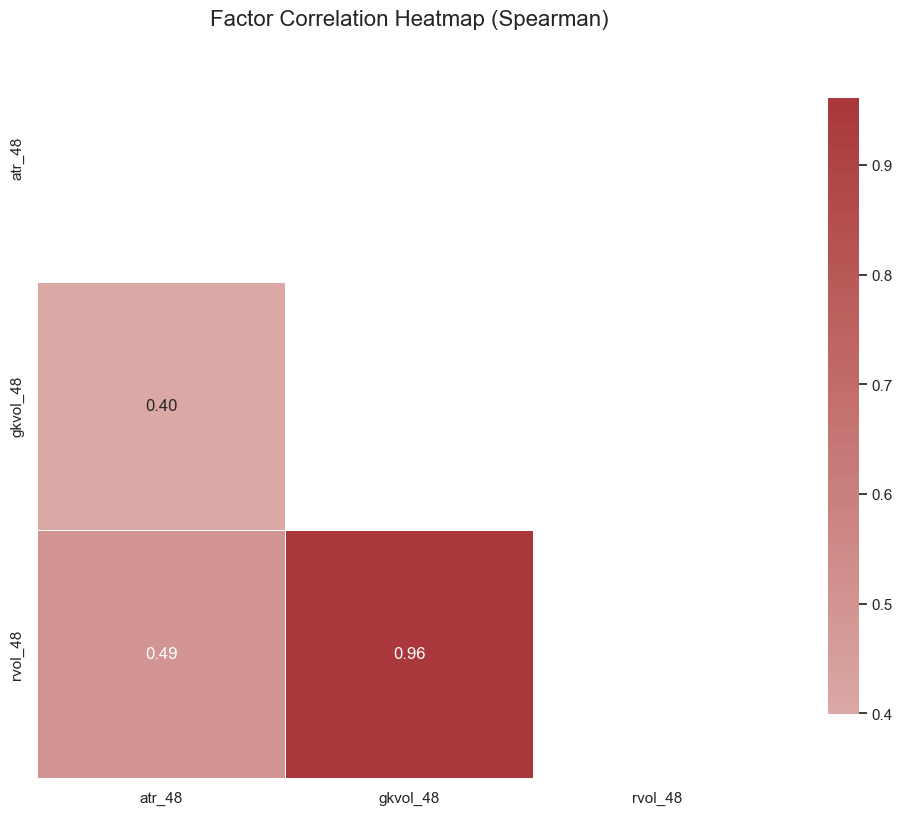

Group 8 Average Spearman IC: 0.3840
Group 9 Correlation Heatmap:


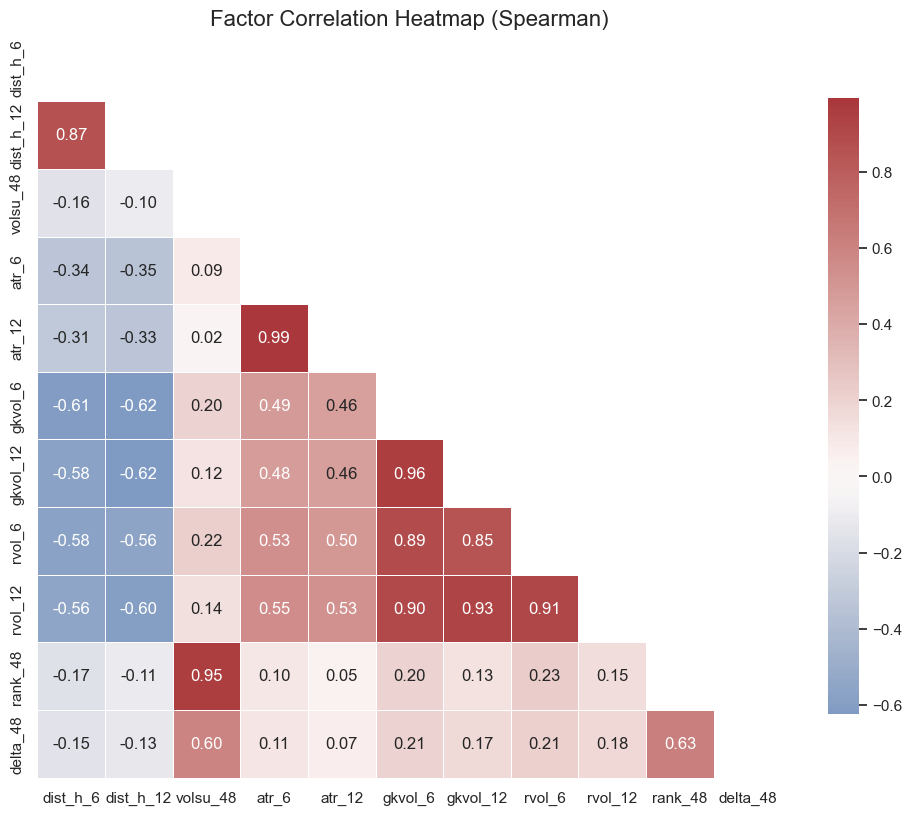

Group 9 Average Spearman IC: 0.1955


In [21]:
group_eff = [0, 3, 8, 9]
for i in group_eff:
    factor_list = group_split[i]
    df_group = factors[factor_list]
    print(f"Group {i} Correlation Heatmap:")
    plot_factor_corr(df_group, method='spearman')
    ic = df_group.corrwith(target_returns.abs(), method='spearman')
    print(f"Group {i} Average Spearman IC: {ic.mean():.4f}")

In [75]:
from test_tools import effective_days
from test_tools import get_jaccard_similarity

persistence = effective_days(df_final, target_returns.abs(), window = 72, threshold=0.1)
jaccard_similarity = get_jaccard_similarity(persistence)
print("\nFactor Jaccard Similarity Matrix:")
print(jaccard_similarity)


Factor Jaccard Similarity Matrix:
          group_0   group_3   group_8   group_9
group_0  1.000000  0.211426  0.381829  0.427202
group_3  0.211426  1.000000  0.215770  0.232753
group_8  0.381829  0.215770  1.000000  0.436703
group_9  0.427202  0.232753  0.436703  1.000000


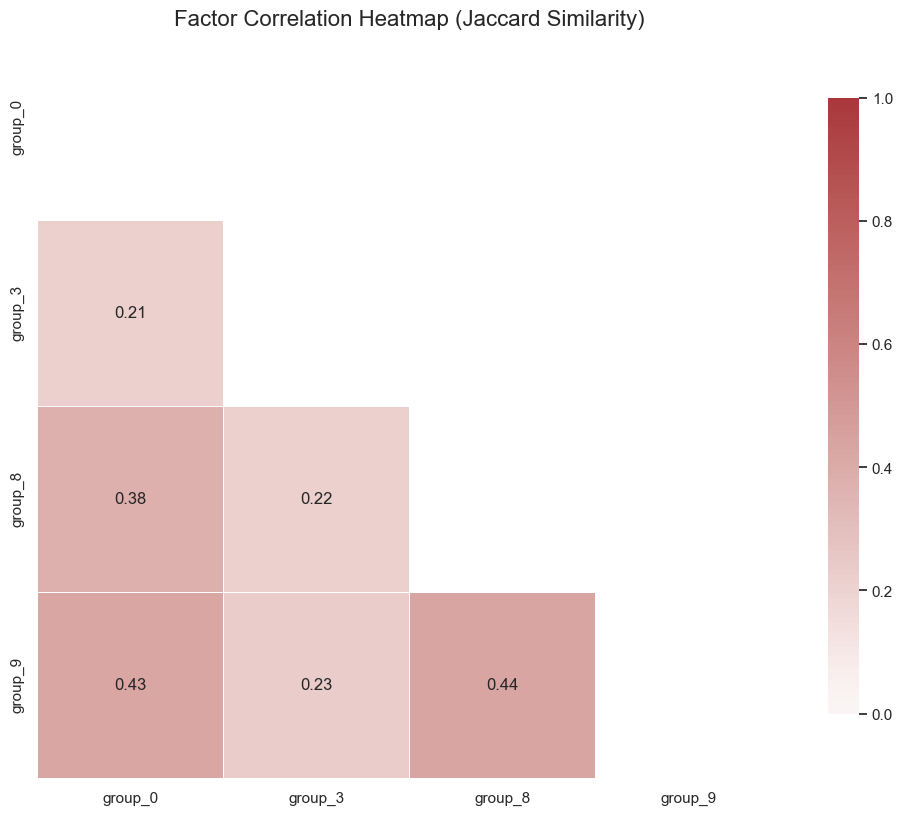

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = jaccard_similarity
sns.set_theme(style="white")
plt.figure(figsize=(12, 10))
    
    # 3. 绘制热力图
    # mask: 隐藏右上角重复的三角形，让视觉更聚焦
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,           # 显示具体数值
    fmt=".2f",            # 保留两位小数
    cmap='vlag',          # 蓝红配色，0为白色，正负分明
    vmin=0,               # 颜色映射下限
    vmax=1,               # 颜色映射上限
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
    )
    
plt.title(f'Factor Correlation Heatmap (Jaccard Similarity)', fontsize=16)
plt.show()

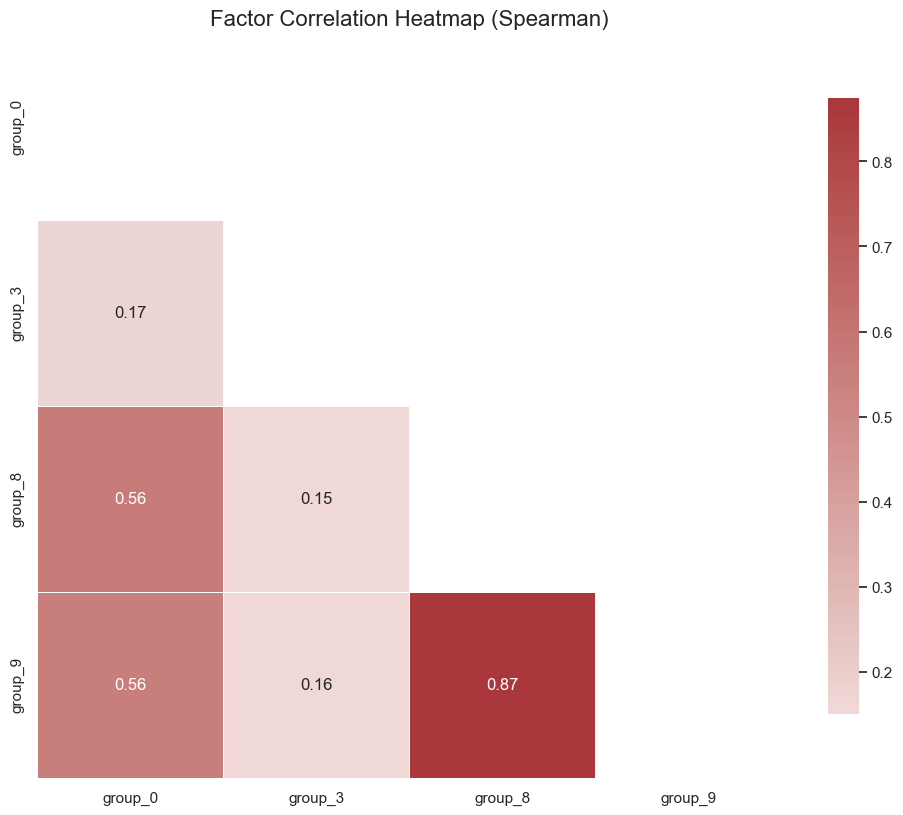

In [68]:
plot_factor_corr(df_final)